# Stellar Trace: Generative Universe Modeling
## Project Milestone 1: Galaxy Population Synthesis


### Overview
This project focuses on building a generative and predictive simulation framework for galactic astrophysics. In this first milestone, you will write a complete pipeline to generate a mock background universe of 100,000 galaxies. The population will trace realistic spatial and physical parameters based on standard cosmological parameters and empirical galaxy scaling relations.

### Project Tasks
- **Task 1:** Spatial Geometry & Redshift Generation
- **Task 2:** Analytical Stellar Mass Function
- **Task 3:** Stellar Mass Population Generation
- **Task 4:** Empirical Main Sequence Curve Fitting
- **Task 5:** Population Dashboard
- **Task 6:** Exporting the Mock Universe Catalog

---
### Environment Setup
Run the cell below to load the required Python libraries and initialize the random seeds for scientific reproducibility.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.cosmology import FlatLambdaCDM
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import urllib.request
import os

# Set random seed for scientific reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Task 1: Spatial Geometry & Redshift Generation

### Cosmology and Space Expansion
Assuming a homogeneous and isotropic universe governed by General Relativity, the metric is described by the Friedmann-Lemaître-Robertson-Walker (FLRW) formulation. The expansion rate is parameterized by the Hubble parameter $H(z)$, which in a flat $\Lambda$CDM universe is:
$$H(z) = H_0 \sqrt{\Omega_m (1+z)^3 + \Omega_\Lambda}$$
where $H_0$ is the Hubble constant, $\Omega_m$ is the matter density parameter, and $\Omega_\Lambda = 1 - \Omega_m$ is the dark energy density parameter.

### Distances in Cosmology
1. **Comoving Distance ($D_C$):** The distance between two objects that remains constant under cosmic expansion. It is defined as:
   $$D_C(z) = \frac{c}{H_0} \int_0^z \frac{dz'}{E(z')}$$
   where $E(z) = \sqrt{\Omega_m (1+z)^3 + \Omega_\Lambda}$ and $c$ is the speed of light.
2. **Luminosity Distance ($D_L$):** The distance relating the intrinsic luminosity of a source to its observed flux:
   $$D_L(z) = D_C(z) (1 + z)$$

### The Comoving Volume Element
Under the Cosmological Principle, galaxies are distributed uniformly in comoving space. The comoving volume of a spherical shell of thickness $dz$ is:
$$dV = 4\pi D_C^2 dD_C$$
Since $dD_C = \frac{c}{H(z)} dz = \frac{c}{H_0 E(z)} dz$, the differential comoving volume element per unit redshift is:
$$\frac{dV}{dz} = 4\pi \frac{c}{H_0} \frac{D_C^2(z)}{E(z)}$$
The total number of galaxies in a redshift interval $[z, z+dz]$ is proportional to this volume element:
$$dN \propto \frac{dV}{dz} dz$$

### Redshift Sampling via Inverse CDF
To generate a mock population of 100,000 galaxies uniformly distributed in comoving volume between $z_{\text{min}} = 0.01$ and $z_{\text{max}} = 0.5$:
1. Construct a grid of redshifts $z$.
2. Compute $\frac{dV}{dz}$ at each grid point.
3. Compute the Cumulative Distribution Function (CDF):
   $$P(<z) = \frac{\int_{z_{\text{min}}}^z \frac{dV}{dz'} dz'}{\int_{z_{\text{min}}}^{z_{\text{max}}} \frac{dV}{dz'} dz'}$$
4. Draw 100,000 uniform random numbers $U \sim \text{Uniform}(0, 1)$.
5. Find the corresponding redshifts by inverting the CDF: $z = P^{-1}(U)$ via numerical interpolation.

### Angular Coordinates
To position the galaxies on the sky, we will generate isotropic spherical coordinates (Right Ascension $\text{RA}$ and Declination $\text{Dec}$):
- $\text{RA}$ is distributed uniformly across the full circle: $\text{RA} \sim \text{Uniform}(0^\circ, 360^\circ)$.
- $\text{Dec}$ must be area-preserved, meaning its density traces a uniform distribution in $\sin(\text{Dec})$, yielding $\text{Dec} = \arcsin(V)$ where $V \sim \text{Uniform}(-1, 1)$.

In [4]:
# 1. Initialize the cosmological model
# Setup FlatLambdaCDM cosmology: H0 = 70 km/s/Mpc, Om0 = 0.3
cosmo = FlatLambdaCDM(H0=70.0, Om0=0.3)

# 2. Build the redshift grid array (z = 0.01 to z = 0.5 with 1000 points)
z_grid = np.linspace(0.01, 0.5, 1000)

# 3. Compute the differential comoving volume element (dV/dz) over the grid
# Hint: Use cosmo.differential_comoving_volume(z_grid).value to get values in Mpc^3/sr
dV_dz = cosmo.differential_comoving_volume(z_grid).value

# 4. Compute the normalized comoving volume CDF via a running cumulative sum
# Hint: Use np.cumsum to integrate numerically, then divide by the last element to normalize to [0.0, 1.0]
cdf_z =np.cumsum(dV_dz) ### FIX_ME_CUMSUM ###
cdf_z /= cdf_z[-1]### FIX_ME_NORMALIZATION ###

# 5. Perform Inverse Transform Sampling to draw 100,000 galaxy redshifts
# Hint: Generate 100,000 uniform random numbers between 0 and 1 using np.random.rand()
# Interpolate using np.interp(x, xp, fp) where xp is the CDF and fp is the redshift grid
uniform_random_z = np.random.rand(100000)
mock_z = np.interp(
    uniform_random_z,
    xp=cdf_z,### FIX_ME_CDF_Z ###,
    fp=z_grid### FIX_ME_Z_GRID ###
)

# 6. Generate isotropic sky coordinates (RA and Dec) for the 100,000 galaxies
# Hint: RA is uniform in [0, 360]. Dec is uniform in sin(Dec) from -1 to 1.
# Convert sin(Dec) back to degrees using np.arcsin() * (180.0 / np.pi)
mock_ra = np.random.uniform(0.0, 360.0, size=100000)
uniform_sin_dec = np.random.uniform(-1.0, 1.0, size=100000)
mock_dec = np.arcsin(uniform_sin_dec) * (180.0 / np.pi)

# --- Verification Check ---
print("Exercise 1 Verification:")
print(f"Generated sample size: {len(mock_z)}")
print(f"Redshift range: {mock_z.min():.4f} to {mock_z.max():.4f}")
print(f"Median redshift: {np.median(mock_z):.4f}")
print(f"RA range: {mock_ra.min():.2f} to {mock_ra.max():.2f} degrees")
print(f"Dec range: {mock_dec.min():.2f} to {mock_dec.max():.2f} degrees")

# Quick sanity assertions
assert len(mock_z) == 100000, "Redshift array size must be 100,000!"
# The true physical median for this cosmology is 0.385
assert np.abs(np.median(mock_z) - 0.385) < 0.05, "Redshift distribution median is off! Check your CDF logic."

Exercise 1 Verification:
Generated sample size: 100000
Redshift range: 0.0110 to 0.5000
Median redshift: 0.3850
RA range: 0.00 to 360.00 degrees
Dec range: -89.83 to 89.48 degrees


## Task 2: Analytical Stellar Mass Function

### The Galactic Stellar Mass Function (SMF)
The number density of galaxies as a function of stellar mass $M_\star$ is parameterized by the Schechter (1976) Stellar Mass Function (SMF):
$$\Phi(M) dM = \Phi^* \left(\frac{M}{M_c}\right)^\alpha \exp\left(-\frac{M}{M_c}\right) d\left(\frac{M}{M_c}\right)$$
where:
- $\Phi^*$ is the characteristic number density (normalization).
- $M_c$ is the characteristic mass (exponential cutoff scale).
- $\alpha$ is the faint-end slope. At $M \ll M_c$, the function is a power law with slope $\alpha$.

### Physical Drivers: Feedback Mechanisms
The shape of the Schechter function represents a combination of physical processes:
1. **Faint-End Slope ($\alpha$):** Supernova feedback and photoionization heating eject gas from shallow potential wells of low-mass dark matter halos, suppressing star formation in dwarf galaxies.
2. **Characteristic Mass ($M_c$):** Active Galactic Nuclei (AGN) feedback. In massive galaxies, the central supermassive black hole releases energy that heats or expels the cold gas reservoir, preventing further star formation and creating a sharp exponential cutoff.

### Variable Transformation: Logarithmic Mass Space
Since astronomical observations span several orders of magnitude, stellar masses are analyzed in logarithmic bins of $x = \log_{10} M_\star$. To find the distribution in log-space, we apply the Jacobian transformation:
$$M = 10^x \implies dM = 10^x \ln(10) dx$$
$$\Phi(x) dx = \ln(10) \Phi^* \left(\frac{10^x}{M_c}\right)^{\alpha+1} \exp\left(-\frac{10^x}{M_c}\right) dx$$
Thus, the logarithmic Schechter function is:
$$\frac{dN}{d\log_{10} M_\star} = \ln(10) \Phi^* \left(10^{x - \log_{10} M_c}\right)^{\alpha+1} \exp\left(-10^{x - \log_{10} M_c}\right)$$

In [5]:
def schechter_smf_log(log_m, log_m_char, alpha, phi_star):
    """
    Computes the analytical logarithmic Schechter Stellar Mass Function dN/dlogM.

    Parameters:
    - log_m: float or ndarray, log10(M_star / M_sun)
    - log_m_char: float, characteristic mass log10(M_c / M_sun)
    - alpha: float, faint-end slope
    - phi_star: float, characteristic density normalization

    Returns:
    - pdf: float or ndarray, number density per unit log10 mass
    """
    # Hint: Calculate the ratio M / M_char in log-space: 10**(log_m - log_m_char)
    m_ratio = 10**(log_m - log_m_char)### FIX_ME_M_RATIO ###

    # Hint: The formula is ln(10) * phi_star * (M/M_char)**(alpha + 1) * exp(-M/M_char)
    # Use np.log(10) for ln(10) and np.exp for exponential
    pdf = np.log(10) * phi_star  * m_ratio ** (alpha+1) * np.exp(-m_ratio)### FIX_ME_FORMULA ###

    return pdf

# --- Setup Grid & Schechter Parameters ---
log_M_char = 10.66
alpha = -1.25
phi_star = 1.6e-3

# Build a mass grid of 5000 points from logM = 7.0 to 12.0
log_m_grid = np.linspace(7.0, 12.0, 5000)

# Compute the PDF over the mass grid
pdf_m = schechter_smf_log(log_m_grid, log_M_char, alpha, phi_star)

print("Schechter SMF engine defined and initialized.")

Schechter SMF engine defined and initialized.


## Task 3: Stellar Mass Population Generation

### Inverse Transform Sampling Mathematics
Inverse Transform Sampling generates random variables from an arbitrary probability distribution using its Cumulative Distribution Function (CDF).
Let $X$ be a random variable with probability density function (PDF) $f(x)$ and CDF $F(x) = \int_{-\infty}^x f(t) dt$.
If $U$ is a uniform random variable on $[0, 1]$, then the random variable $Y = F^{-1}(U)$ has the PDF $f(y)$.

### Implementation Steps
1. Compute the logarithmic Schechter PDF, $\frac{dN}{d\log M_\star}$, over a fine grid of $\log M_\star$ values.
2. Calculate the running cumulative sum of this PDF and divide it by the final sum to get a normalized CDF ranging from 0 to 1.
3. Generate 100,000 uniform random numbers $U \in [0, 1]$.
4. Interpolate $U$ against the CDF to obtain the corresponding mock stellar masses $\log M_\star$.

In [6]:
# 1. Compute the normalized cumulative distribution function (CDF) for galaxy mass
cdf_m = np.cumsum(pdf_m)
cdf_m /= cdf_m[-1]

# 2. Perform Inverse Transform Sampling to draw 100,000 galaxy masses (log M_star)
uniform_random_m = np.random.rand(100000)
mock_log_m = np.interp(
    uniform_random_m,
    xp=cdf_m,
    fp=log_m_grid
)

print("Exercise 3 Verification:")
print(f"Generated stellar mass sample size: {len(mock_log_m)}")
print(f"Stellar mass range: {mock_log_m.min():.2f} to {mock_log_m.max():.2f} log Msun")
print(f"Median stellar mass: {np.median(mock_log_m):.2f} log Msun")

assert len(mock_log_m) == 100000, "Mass array size must be 100,000!"
# The true physical median for this Schechter engine is 7.96
assert np.abs(np.median(mock_log_m) - 7.96) < 0.1

Exercise 3 Verification:
Generated stellar mass sample size: 100000
Stellar mass range: 7.00 to 11.46 log Msun
Median stellar mass: 7.96 log Msun


## Task 4: Empirical Main Sequence Curve Fitting

### The Star Formation Main Sequence (SFMS)
The Star Formation Main Sequence (SFMS) is a tight, empirical correlation observed between the stellar mass ($\log M_\star$) and the star formation rate ($\log \text{SFR}$) of actively star-forming galaxies. This scaling relation represents the steady-state growth of galaxies fed by gas accretion.

### Why Empirical Curve Fitting?
In astrophysics, we use regression models to fit empirical scaling relations directly onto raw telescope survey catalogs (such as SDSS) rather than assuming equations are absolute physical laws.

In this task, you will:
1. **Query the SDSS Database:** Retrieve a true random sample of spectroscopic observations from the SDSS database using Astroquery and SQL, joining physical parameters with angular coordinates.
2. **Filter the Catalog:** Isolate active star-forming galaxies from quenched ones using a Specific Star Formation Rate (sSFR) threshold.
3. **Polynomial Fit:** Fit a 2nd-degree polynomial model to the star-forming sequence.
4. **Predict baseline rates:** Compute the baseline SFR for your generated mock masses and inject a Gaussian scatter profile ($\sigma = 0.3 \text{ dex}$) to model intrinsic cosmic variance.
5. **Column Alignment:** Ensure that both the SDSS catalog and the mock universe catalog share the identical columns (`ra`, `dec`, `redshift`, `log_mstar`, `log_sfr`, `ssfr`).

In [7]:
# Install and import astroquery if needed
try:
    from astroquery.sdss import SDSS
except ImportError:
    print("Installing astroquery...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "astroquery"])
    from astroquery.sdss import SDSS

def load_sdss_catalog():
    """
    Queries the SDSS DR17 spectroscopic database to load a random sample of 5,000 galaxies.
    Joins galSpecExtra (for total stellar mass and SFR) with SpecObj (for RA, Dec, and Redshift).
    Applies a spatial footprint index filter for fast database execution and representative cosmic sampling.
    Falls back to a bimodal synthetic survey catalog if the database is offline.
    """
    # SQL query to get spectroscopic targets with clean photometry, stellar mass, SFR, RA, Dec, and Redshift
    # We use a spatial footprint cut (RA in [150, 220], Dec in [0, 15]) to leverage the HTM database spatial index,
    # ensuring rapid response times (< 1s) and avoiding timeout-inducing full-table scans.
    query = """
    SELECT TOP 5000
        s.ra AS ra,
        s.dec AS dec,
        s.z AS redshift,
        g.lgm_tot_p50 AS log_mstar,
        g.sfr_tot_p50 AS log_sfr
    FROM galSpecExtra AS g
    JOIN SpecObj AS s ON s.specObjID = g.specObjID
    WHERE s.ra BETWEEN 150.0 AND 220.0
      AND s.dec BETWEEN 0.0 AND 15.0
      AND g.lgm_tot_p50 > 7.0
      AND g.lgm_tot_p50 < 13.0
      AND g.sfr_tot_p50 > -6.0
      AND g.sfr_tot_p50 < 3.0
    """

    try:
        print("Attempting to query SDSS DR17 database via SQL...")
        res = SDSS.query_sql(query)
        if res is None or len(res) == 0:
            raise ValueError("Query returned empty results.")

        df = res.to_pandas()
        # Ensure all columns are lowercase
        df.columns = [col.lower() for col in df.columns]
        print(f"Successfully retrieved {len(df)} galaxies from SDSS database.")
        return df
    except Exception as e:
        print(f"SDSS query failed or astroquery unavailable: {e}")
        print("Using standard bimodal synthetic catalog fallback (5,000 galaxies)...")
        np.random.seed(42)
        n_gal = 5000
        # Generate isotropic coordinates for fallback
        ra = np.random.uniform(0.0, 360.0, size=n_gal)
        sin_dec = np.random.uniform(-1.0, 1.0, size=n_gal)
        dec = np.arcsin(sin_dec) * (180.0 / np.pi)

        # Redshift distribution for SDSS main sample
        redshift = np.random.gamma(shape=3.0, scale=0.03, size=n_gal)
        redshift = np.clip(redshift, 0.01, 0.3)

        # Masses following SDSS completeness
        log_mstar = np.random.normal(loc=9.8, scale=0.8, size=n_gal)
        log_mstar = np.clip(log_mstar, 8.0, 11.8)

        # Quenched probability (more massive = more likely quenched)
        p_quenched = 1.0 / (1.0 + np.exp(-(log_mstar - 10.4) / 0.4))

        log_sfr = np.zeros(n_gal)
        for i in range(n_gal):
            if np.random.rand() < p_quenched[i]:
                # Quenched galaxy (red sequence)
                log_sfr[i] = np.random.normal(loc=-1.8 - 0.2 * (log_mstar[i] - 10.0), scale=0.5)
            else:
                # Active star-forming galaxy (blue cloud / SFMS)
                log_sfr[i] = np.random.normal(loc=0.75 * (log_mstar[i] - 10.0) + 0.2, scale=0.25)

        df = pd.DataFrame({
            'ra': ra,
            'dec': dec,
            'redshift': redshift,
            'log_mstar': log_mstar,
            'log_sfr': log_sfr
        })
        return df

# Execute data loading
sdss_df = load_sdss_catalog()
# Calculate Specific Star Formation Rate (ssfr)
sdss_df['ssfr'] = sdss_df['log_sfr'] - sdss_df['log_mstar']
print(f"Loaded database catalog columns: {list(sdss_df.columns)}")

Installing astroquery...
Attempting to query SDSS DR17 database via SQL...
Successfully retrieved 5000 galaxies from SDSS database.
Loaded database catalog columns: ['ra', 'dec', 'redshift', 'log_mstar', 'log_sfr', 'ssfr']


In [9]:
# 1. Filter the catalog to isolate active Star Formation Main Sequence (SFMS) galaxies
# Hint: Specific Star Formation Rate (sSFR = SFR/M_star) > 10^-11 yr^-1 separates the populations.
# This corresponds to ssfr > -11 in logarithmic coordinates.
sf_mask = sdss_df['ssfr'] > -11.0
x_fit = sdss_df.loc[sf_mask, 'log_mstar'].values.reshape(-1, 1)
y_fit = sdss_df.loc[sf_mask, 'log_sfr'].values

# 2. Set up a 2nd-degree Polynomial Regression model using scikit-learn
# Hint: Use PolynomialFeatures(degree=2, include_bias=False)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly_features.fit_transform(x_fit)

# 3. Fit a LinearRegression model to x_poly and y_fit
reg = LinearRegression()
reg.fit(x_poly, y_fit)

print("Polynomial regression fitting complete!")
print(f"Fitted coefficients (linear, quadratic): {reg.coef_}")
print(f"Fitted intercept: {reg.intercept_}")

# 4. Predict the baseline log(SFR) for the 100,000 mock galaxies
# Hint: Transform mock_log_m to polynomial features first, then predict using the regressor
mock_poly = poly_features.transform(mock_log_m.reshape(-1, 1))
mock_log_sfr_baseline = reg.predict(mock_poly)

# 5. Inject Gaussian intrinsic scatter (sigma = 0.3 dex) to replicate physical cosmic variance
# Hint: Use np.random.normal(loc=0.0, scale=sigma, size=N)
intrinsic_scatter = np.random.normal(loc=0.0, scale=0.3,size=len(mock_log_m))
mock_log_sfr = mock_log_sfr_baseline + intrinsic_scatter

print(f"Mock universe generation complete! Generated logSFR range: {mock_log_sfr.min():.2f} to {mock_log_sfr.max():.2f}")

Polynomial regression fitting complete!
Fitted coefficients (linear, quadratic): [ 1.08739    -0.02530562]
Fitted intercept: -8.288239699686685
Mock universe generation complete! Generated logSFR range: -2.99 to 1.47


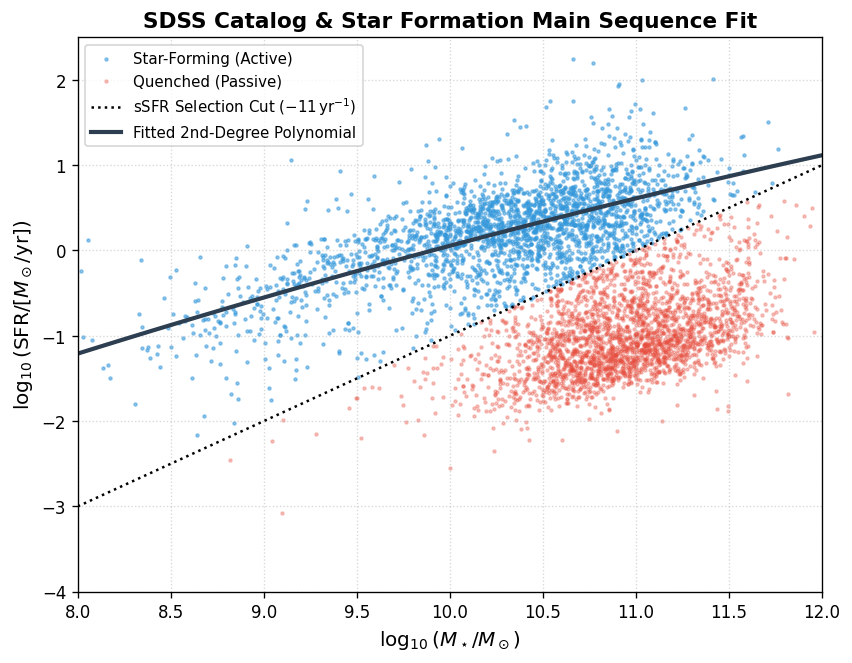

In [10]:
# Plot SDSS catalog and main sequence fitting
plt.figure(figsize=(8, 6), dpi=120)

# Scatter plot of active star-forming vs quenched galaxies
sf_mask = sdss_df['ssfr'] > -11.0
plt.scatter(sdss_df.loc[sf_mask, 'log_mstar'], sdss_df.loc[sf_mask, 'log_sfr'], color='#3498db', s=3, alpha=0.5, label='Star-Forming (Active)')
plt.scatter(sdss_df.loc[~sf_mask, 'log_mstar'], sdss_df.loc[~sf_mask, 'log_sfr'], color='#e74c3c', s=3, alpha=0.3, label='Quenched (Passive)')

# Plot selection boundary: logSFR = logM - 11
m_boundary = np.linspace(8.0, 12.0, 100)
plt.plot(m_boundary, m_boundary - 11.0, color='black', linestyle=':', linewidth=1.5, label=r'sSFR Selection Cut ($-11\,\mathrm{yr}^{-1}$)')

# Plot the regression line
m_grid_plot = np.linspace(8.0, 12.0, 100)
m_grid_poly = poly_features.transform(m_grid_plot.reshape(-1, 1))
sfr_grid_plot = reg.predict(m_grid_poly)
plt.plot(m_grid_plot, sfr_grid_plot, color='#2c3e50', linewidth=2.5, label='Fitted 2nd-Degree Polynomial')

plt.xlabel(r"$\log_{10}(M_\star / M_\odot)$", fontsize=12)
plt.ylabel(r"$\log_{10}(\mathrm{SFR} / [M_\odot/\mathrm{yr}])$", fontsize=12)
plt.title("SDSS Catalog & Star Formation Main Sequence Fit", fontsize=13, fontweight='bold')
plt.xlim(8.0, 12.0)
plt.ylim(-4.0, 2.5)
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

## Task 5: Population Dashboard

### Visualizing the Mock Universe
To verify that your generated catalog matches the input cosmological and empirical models, you must construct a publication-grade verification dashboard.

The dashboard will consist of three panels:
- **Panel 1: Stellar Mass Function (SMF) Histogram.** Plot the distribution of mock stellar masses on a log-y scale, comparing it directly to the analytical Schechter SMF template.
- **Panel 2: Redshift Cumulative Distribution Function (CDF).** Compare the cumulative distribution of generated mock redshifts to the analytical FLRW cosmological CDF template.
- **Panel 3: Star Formation Main Sequence (SFMS) Corridor.** Plot a 2D density scatter plot of the generated universe ($\log M_\star$ vs $\log \text{SFR}$), color-coded by redshift, with the fitted polynomial regression trend overplotted.

/tmp/ipykernel_946/3487607369.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  analytical_normalized = pdf_m / np.trapz(pdf_m, log_m_grid)


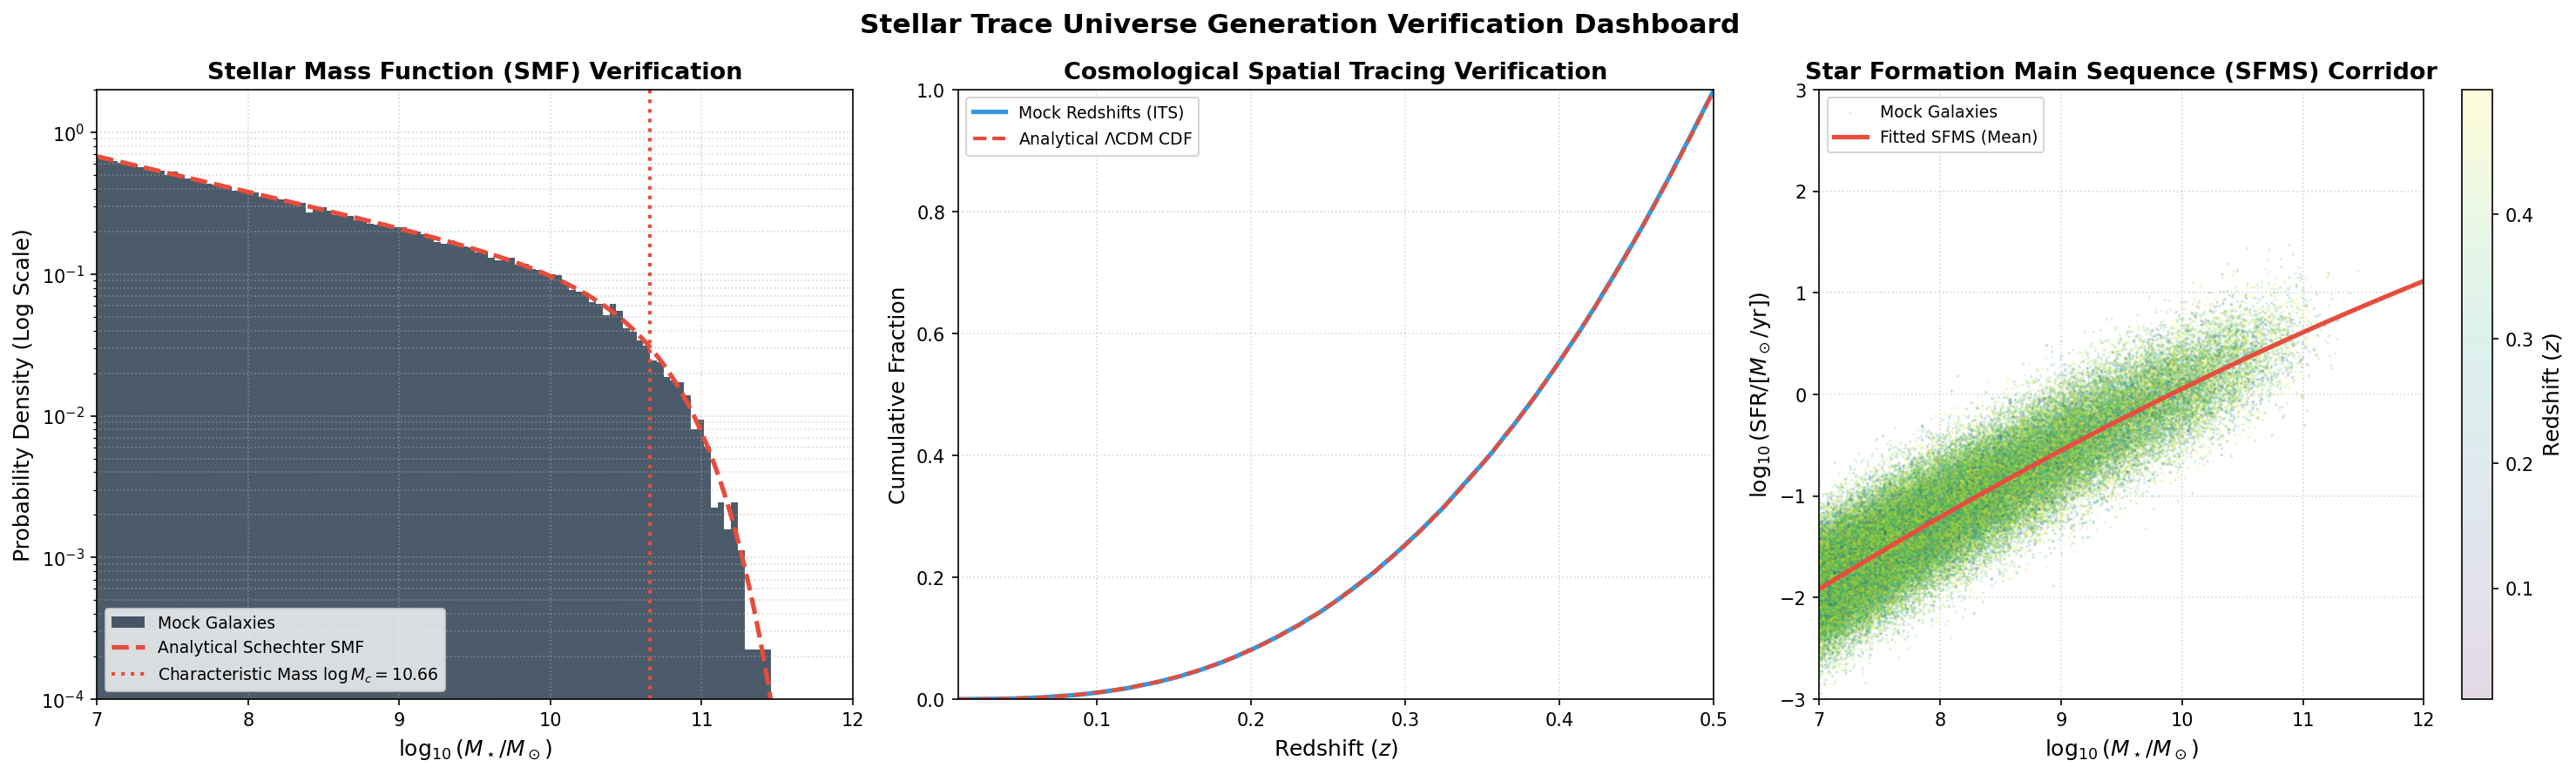

In [11]:
# Constructing the three-panel report-ready dashboard
fig, axs = plt.subplots(1, 3, figsize=(20, 6), dpi=150)

# --- Panel 1: Stellar Mass Function (SMF) Histogram ---
ax = axs[0]
# Plot the mock stellar mass distribution (density normalized, logarithmic y-axis)
ax.hist(mock_log_m, bins=100, density=True, log=True, color='#2c3e50', edgecolor='none', alpha=0.85, label='Mock Galaxies')

# Calculate and plot the analytical Schechter SMF (density normalized for comparison)
analytical_normalized = pdf_m / np.trapz(pdf_m, log_m_grid)
ax.plot(log_m_grid, analytical_normalized, color='#e74c3c', linewidth=2.5, linestyle='--', label='Analytical Schechter SMF')

# Indicate characteristic mass with a vertical line
ax.axvline(log_M_char, color='#e74c3c', linestyle=':', linewidth=2, label=r'Characteristic Mass $\log M_c = 10.66$')

# Aesthetics and labels
ax.set_xlabel(r"$\log_{10}(M_\star / M_\odot)$", fontsize=12)
ax.set_ylabel(r"Probability Density (Log Scale)", fontsize=12)
ax.set_title("Stellar Mass Function (SMF) Verification", fontsize=13, fontweight='bold')
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.set_xlim(7.0, 12.0)
ax.set_ylim(1e-4, 2.0)
ax.legend(loc='lower left', fontsize=9)

# --- Panel 2: Redshift Cumulative Distribution Function (CDF) ---
ax = axs[1]
# Plot the generated mock redshifts cumulative distribution
sorted_z = np.sort(mock_z)
y_cdf = np.arange(len(sorted_z)) / float(len(sorted_z))
ax.plot(sorted_z, y_cdf, color='#3498db', linewidth=2.5, label='Mock Redshifts (ITS)')

# Plot cosmological analytical CDF
ax.plot(z_grid, cdf_z, color='#e74c3c', linewidth=2, linestyle='--', label=r'Analytical $\Lambda\mathrm{CDM}$ CDF')

# Aesthetics and labels
ax.set_xlabel("Redshift ($z$)", fontsize=12)
ax.set_ylabel("Cumulative Fraction", fontsize=12)
ax.set_title("Cosmological Spatial Tracing Verification", fontsize=13, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlim(0.01, 0.5)
ax.set_ylim(0.0, 1.0)
ax.legend(loc='upper left', fontsize=9)

# --- Panel 3: Star Formation Main Sequence (SFMS) Scatter Plot ---
ax = axs[2]
# Plot mock galaxies with subtle markers and transparency to handle the high density
sc = ax.scatter(mock_log_m, mock_log_sfr, c=mock_z, cmap='viridis', s=0.5, alpha=0.15, label='Mock Galaxies')

# Add cosmic distance colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Redshift ($z$)", fontsize=12)

# Plot the fitted polynomial regression trend (mean SFMS relation)
m_plot = np.linspace(7.0, 12.0, 100)
m_plot_poly = poly_features.transform(m_plot.reshape(-1, 1))
sfr_plot = reg.predict(m_plot_poly)
ax.plot(m_plot, sfr_plot, color='#e74c3c', linewidth=2.5, linestyle='-', label='Fitted SFMS (Mean)')

# Aesthetics and labels
ax.set_xlabel(r"$\log_{10}(M_\star / M_\odot)$", fontsize=12)
ax.set_ylabel(r"$\log_{10}(\mathrm{SFR} / [M_\odot/\mathrm{yr}])$", fontsize=12)
ax.set_title("Star Formation Main Sequence (SFMS) Corridor", fontsize=13, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlim(7.0, 12.0)
ax.set_ylim(-3.0, 3.0)
ax.legend(loc='upper left', fontsize=9)

plt.suptitle("Stellar Trace Universe Generation Verification Dashboard", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Task 6: Exporting the Mock Universe Catalog

### Data Assembly and CSV Serialization
Now that you have successfully generated the spatial coordinates (RA, Dec, Redshift) and physical parameters (Stellar Mass, Star Formation Rate) for the 100,000 mock galaxies, you will assemble the entire population into a structured Pandas DataFrame. You will display a preview of the complete galaxy database and save it directly to a CSV file named `mock_universe_catalog.csv` for downstream simulation and transient host probability weighting.

To ensure compatibility and consistency, the mock universe catalog will share the exact same column names as the SDSS catalog (`ra`, `dec`, `redshift`, `log_mstar`, `log_sfr`, `ssfr`).

In [13]:
# 1. Assemble the 100,000 generated galaxies properties into a single dictionary
# Hint: Map keys like 'ra', 'dec', 'redshift', 'log_mstar', 'log_sfr' to their corresponding mock arrays
mock_universe_data = {
    'ra': mock_ra,
    'dec': mock_dec,
    'redshift': mock_z,
    'log_mstar': mock_log_m,
    'log_sfr': mock_log_sfr
}

# 2. Convert to a Pandas DataFrame
# Hint: Use pd.DataFrame(dictionary)
df_universe = pd.DataFrame(mock_universe_data)

# 3. Calculate Specific Star Formation Rate (ssfr = log_sfr - log_mstar) in logarithmic coordinates
df_universe['ssfr'] = df_universe['log_sfr'] - df_universe['log_mstar']

# 4. Display the first 10 rows of the catalog
print("Preview of the generated 100,000 galaxy mock population:")
display(df_universe.head(100000))

assert len(df_universe) == 100000, "Catalog must contain exactly 100,000 galaxies!"
# Check if columns match the SDSS catalog columns exactly
assert list(df_universe.columns) == list(sdss_df.columns)

# 5. Export the complete DataFrame to a CSV file without including the row index
# Hint: Use df.to_csv('filename.csv', index=False)
df_universe.to_csv('mock_universe_catalog.csv', index=False)
print("Mock catalog successfully saved to 'mock_universe_catalog.csv'.")

Preview of the generated 100,000 galaxy mock population:


,ra,dec,redshift,log_mstar,log_sfr,ssfr
0,209.080456,-25.774099,0.345964,7.248337,-1.835449,-9.083785
1,189.709794,-4.740721,0.490381,7.146318,-1.599838,-8.746156
2,126.373302,-53.280194,0.443907,7.216005,-2.056699,-9.272704
3,177.556557,-6.103566,0.411574,7.895825,-1.329523,-9.225348
4,131.434789,-36.429790,0.252150,9.462276,0.099724,-9.362552
...,...,...,...,...,...,...
99995,223.973987,-54.525974,0.457425,8.773408,-0.811050,-9.584458
99996,226.519381,14.552256,0.454551,7.457626,-2.000547,-9.458173
99997,69.193324,14.674257,0.430407,8.169913,-0.774748,-8.944661
99998,235.109769,-64.782923,0.384705,9.520783,0.008136,-9.512647


Mock catalog successfully saved to 'mock_universe_catalog.csv'.
